# Tier 3 — Hybrid Retrieval: Full Analysis

**Benchmark:** BSARD official test split — 222 questions  
**Experiments:** 15 hybrid fusion configurations (T3-A RRF, T3-B Linear, T3-C SGDR)  
**Primary metric:** Recall@10 | **Anchor:** `dense_me5_large_concat2x_zeroshot` (R@10=0.3420)  
**Sparse backbone:** `bm25_tuned_k11.5_b0.25` (k1=1.5, b=0.25, lemmatize, text_only)  
**Dense backbone:** `intfloat/multilingual-e5-large` (concat_2x field weighting)  
**Corpus:** 22,633 deduplicated articles (`output/bsard_articles_dedup.parquet`)

---

### Experiment Map

| Group | Method | Experiments | Description |
|-------|---------|-------------|-------------|
| T3-A | RRF | k=30, 60, 120 | Reciprocal Rank Fusion, first_stage_k=100 |
| T3-B | Linear | α=0.1–0.9 | Linear score blend: α·dense + (1−α)·BM25_norm |
| T3-C | SGDR | pool_k=1000, 2000, 5000 | Sparse-Gated Dense Reranking: BM25 top-K → dense re-score |
| ~~T3-A2~~ | ~~BGE-M3 self-hybrid~~ | ~~skipped~~ | BGE-M3 (D4c) did not win Tier 2; mE5-large (D4) was selected — T3-A2 condition not met |

## 0. Setup

In [16]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

ROOT        = Path().resolve().parent.parent
HYBRID_DIR  = ROOT / 'output' / 'results' / 'hybrid'
DENSE_DIR   = ROOT / 'output' / 'results' / 'dense_retrieval'
SPARSE_DIR  = ROOT / 'output' / 'results' / 'sparse_retrieval'
IMG_DIR     = Path().resolve() / 'img'
IMG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

# ── Load all hybrid results ────────────────────────────────────────────────
raw = {}
for f in sorted(HYBRID_DIR.glob('*_test.json')):
    d = json.loads(f.read_text(encoding='utf-8'))
    stem = d['experiment_id'].replace('_test', '')
    raw[stem] = d

# ── Load reference anchors ─────────────────────────────────────────────────
SPARSE_KEY = 'bm25_tuned_k11.5_b0.25'
DENSE_KEY  = 'dense_me5_large_concat2x_zeroshot'

sparse_raw = {}
for f in SPARSE_DIR.glob('*_test.json'):
    d = json.loads(f.read_text(encoding='utf-8'))
    sparse_raw[d['experiment_id'].replace('_test', '')] = d

dense_raw = {}
for f in DENSE_DIR.glob('*_test.json'):
    d = json.loads(f.read_text(encoding='utf-8'))
    dense_raw[d['experiment_id'].replace('_test', '')] = d

print(f'Hybrid experiments loaded : {len(raw)}')
for k in sorted(raw):
    m = raw[k]['metrics']
    print(f'  {k:<45}  R@10={m["Recall@10"]:.4f}  R@100={m["Recall@100"]:.4f}')

Hybrid experiments loaded : 15
  hybrid_linear_alpha_0.1                        R@10=0.2909  R@100=0.5210
  hybrid_linear_alpha_0.2                        R@10=0.3292  R@100=0.5248
  hybrid_linear_alpha_0.3                        R@10=0.3318  R@100=0.5494
  hybrid_linear_alpha_0.4                        R@10=0.3379  R@100=0.6366
  hybrid_linear_alpha_0.5                        R@10=0.3470  R@100=0.6360
  hybrid_linear_alpha_0.6                        R@10=0.3515  R@100=0.6215
  hybrid_linear_alpha_0.7                        R@10=0.3518  R@100=0.6215
  hybrid_linear_alpha_0.8                        R@10=0.3611  R@100=0.6215
  hybrid_linear_alpha_0.9                        R@10=0.3837  R@100=0.6215
  hybrid_rrf_k120                                R@10=0.4015  R@100=0.6513
  hybrid_rrf_k30                                 R@10=0.3972  R@100=0.6513
  hybrid_rrf_k60                                 R@10=0.4021  R@100=0.6513
  hybrid_sgdr_k1000                              R@10=0.3655  R@100=0

In [17]:
# ── Display labels and colour palette ─────────────────────────────────────
SHORT = {
    'hybrid_rrf_k30':          'RRF k=30 (T3-A)',
    'hybrid_rrf_k60':          'RRF k=60 (T3-A) [best]',
    'hybrid_rrf_k120':         'RRF k=120 (T3-A)',
    'hybrid_linear_alpha_0.1': 'Linear α=0.1 (T3-B)',
    'hybrid_linear_alpha_0.2': 'Linear α=0.2 (T3-B)',
    'hybrid_linear_alpha_0.3': 'Linear α=0.3 (T3-B)',
    'hybrid_linear_alpha_0.4': 'Linear α=0.4 (T3-B)',
    'hybrid_linear_alpha_0.5': 'Linear α=0.5 (T3-B)',
    'hybrid_linear_alpha_0.6': 'Linear α=0.6 (T3-B)',
    'hybrid_linear_alpha_0.7': 'Linear α=0.7 (T3-B)',
    'hybrid_linear_alpha_0.8': 'Linear α=0.8 (T3-B)',
    'hybrid_linear_alpha_0.9': 'Linear α=0.9 (T3-B) [best]',
    'hybrid_sgdr_k1000':       'SGDR pool=1000 (T3-C) [best]',
    'hybrid_sgdr_k2000':       'SGDR pool=2000 (T3-C)',
    'hybrid_sgdr_k5000':       'SGDR pool=5000 (T3-C)',
}

# Group colours
COLORS = {}
for k in raw:
    if 'rrf' in k:    COLORS[k] = '#2e86c1'   # blue
    elif 'linear' in k: COLORS[k] = '#27ae60'  # green
    elif 'sgdr' in k:   COLORS[k] = '#e67e22'  # orange

SPARSE_COLOR = '#e74c3c'   # red
DENSE_COLOR  = '#8e44ad'   # purple

# Anchor metrics
DENSE_R10  = dense_raw[DENSE_KEY]['metrics']['Recall@10']   if DENSE_KEY  in dense_raw  else 0
DENSE_R100 = dense_raw[DENSE_KEY]['metrics']['Recall@100']  if DENSE_KEY  in dense_raw  else 0
SPARSE_R10 = sparse_raw[SPARSE_KEY]['metrics']['Recall@10'] if SPARSE_KEY in sparse_raw else 0
SPARSE_R100= sparse_raw[SPARSE_KEY]['metrics']['Recall@100']if SPARSE_KEY in sparse_raw else 0

print(f'Dense anchor  (mE5-large concat_2x): R@10={DENSE_R10:.4f}  R@100={DENSE_R100:.4f}')
print(f'Sparse anchor (bm25_tuned k1.5 b0.25): R@10={SPARSE_R10:.4f}  R@100={SPARSE_R100:.4f}')

Dense anchor  (mE5-large concat_2x): R@10=0.3420  R@100=0.6215
Sparse anchor (bm25_tuned k1.5 b0.25): R@10=0.2651  R@100=0.5210


## A. Full Results Table — All Hybrid Experiments

In [18]:
rows = []
for stem, d in raw.items():
    m   = d['metrics']
    sig = d.get('significance_vs_anchor', {})
    hp  = d['hyperparameters']
    method = hp.get('fusion_method') or hp.get('method', '')
    # Method-specific param
    if method == 'rrf':
        param_label = f"k={hp['rrf_k']}"
    elif method == 'linear':
        param_label = f"α={hp['alpha']}"
    else:
        param_label = f"pool={hp.get('bm25_pool_k', '')}"
    rows.append({
        'Experiment':   SHORT.get(stem, stem),
        'Method':       method,
        'Param':        param_label,
        'R@1':          m.get('Recall@1', 0),
        'R@5':          m.get('Recall@5', 0),
        'R@10':         m.get('Recall@10', 0),
        'R@50':         m.get('Recall@50', 0),
        'R@100':        m.get('Recall@100', 0),
        'R@200':        m.get('Recall@200', 0),
        'R@500':        m.get('Recall@500', 0),
        'MRR@10':       m.get('MRR@10', 0),
        'MRR@100':      m.get('MRR@100', 0),
        'MAP@100':      m.get('MAP@100', 0),
        'NDCG@10':      m.get('NDCG@10', 0),
        'lat_ms':       m.get('T0/latency_mean_ms', d.get('latency_ms_mean', 0)),
        'p_r10':        sig.get('p_value_recall10'),
        'p_r100':       sig.get('p_value_recall100'),
        'sig':          sig.get('significant'),
    })

df = pd.DataFrame(rows).sort_values('R@10', ascending=False).reset_index(drop=True)

# Append anchor reference rows
def _ref_row(key, label, source):
    src = dense_raw if source == 'dense' else sparse_raw
    if key not in src: return None
    m = src[key]['metrics']
    return {'Experiment': label, 'Method': source, 'Param': '—',
            'R@1': m.get('Recall@1',0), 'R@5': m.get('Recall@5',0),
            'R@10': m.get('Recall@10',0), 'R@50': m.get('Recall@50',0),
            'R@100': m.get('Recall@100',0), 'R@200': m.get('Recall@200',0),
            'R@500': m.get('Recall@500',0), 'MRR@10': m.get('MRR@10',0),
            'MRR@100': m.get('MRR@100',0), 'MAP@100': m.get('MAP@100',0),
            'NDCG@10': m.get('NDCG@10',0),
            'lat_ms': m.get('T0/latency_mean_ms',0),
            'p_r10': None, 'p_r100': None, 'sig': None}

refs = pd.DataFrame(filter(None, [
    _ref_row(DENSE_KEY,  '[DENSE] mE5-large concat_2x (anchor)', 'dense'),
    _ref_row(SPARSE_KEY, '[SPARSE] bm25_tuned k1.5 b0.25',       'sparse'),
]))

display_df = pd.concat([df, refs], ignore_index=True)

fmt = {
    'R@1': '{:.4f}', 'R@5': '{:.4f}', 'R@10': '{:.4f}', 'R@50': '{:.4f}',
    'R@100': '{:.4f}', 'R@200': '{:.4f}', 'R@500': '{:.4f}',
    'MRR@10': '{:.4f}', 'MRR@100': '{:.4f}', 'MAP@100': '{:.4f}', 'NDCG@10': '{:.4f}',
    'lat_ms': '{:.1f}', 'p_r10': '{:.4f}', 'p_r100': '{:.4f}',
}
cols = ['Experiment', 'Method', 'Param', 'R@1', 'R@5', 'R@10', 'R@50', 'R@100', 'R@200',
        'MRR@10', 'MRR@100', 'MAP@100', 'NDCG@10', 'lat_ms', 'p_r10', 'p_r100', 'sig']
display(display_df[cols].style.format(fmt, na_rep='—').hide(axis='index'))

Experiment,Method,Param,R@1,R@5,R@10,R@50,R@100,R@200,MRR@10,MRR@100,MAP@100,NDCG@10,lat_ms,p_r10,p_r100,sig
RRF k=60 (T3-A) [best],rrf,k=60,0.1143,0.2910,0.4021,0.5795,0.6513,0.7117,0.3402,0.3496,0.2403,0.3094,321.5,0.0145,0.0619,True
RRF k=120 (T3-A),rrf,k=120,0.1143,0.2905,0.4015,0.5747,0.6513,0.7117,0.3387,0.3486,0.2392,0.3084,325.8,0.0156,0.0619,True
RRF k=30 (T3-A),rrf,k=30,0.1173,0.3036,0.3972,0.5781,0.6513,0.7117,0.3450,0.3544,0.2425,0.3091,326.9,0.0169,0.0619,True
Linear α=0.9 (T3-B) [best],linear,α=0.9,0.1221,0.2947,0.3837,0.5686,0.6215,0.7117,0.3322,0.3402,0.2375,0.3018,649.0,0.0987,1.0000,False
SGDR pool=1000 (T3-C) [best],sparse_gated_dense,pool=1000,0.0978,0.2599,0.3655,0.5423,0.5916,0.6501,0.3271,0.3373,0.2202,0.2851,336.1,0.0825,0.0955,False
Linear α=0.8 (T3-B),linear,α=0.8,0.1233,0.2717,0.3611,0.5686,0.6215,0.7117,0.3152,0.3252,0.2306,0.2871,638.2,0.4592,1.0000,False
SGDR pool=2000 (T3-C),sparse_gated_dense,pool=2000,0.0976,0.2488,0.3538,0.5496,0.6019,0.6641,0.3192,0.3303,0.2174,0.2782,309.8,0.2254,0.2159,False
Linear α=0.7 (T3-B),linear,α=0.7,0.1233,0.2667,0.3518,0.5686,0.6215,0.7117,0.3113,0.3216,0.2276,0.2814,646.7,0.7076,1.0000,False
Linear α=0.6 (T3-B),linear,α=0.6,0.1209,0.2607,0.3515,0.5686,0.6215,0.7117,0.3057,0.3159,0.2250,0.2788,655.7,0.7157,1.0000,False
Linear α=0.5 (T3-B),linear,α=0.5,0.1209,0.2515,0.3470,0.5773,0.6360,0.7117,0.3021,0.3150,0.2231,0.2746,655.6,0.8541,0.0380,False


## 1. Recall@k Curves — All Hybrid Methods vs Anchors

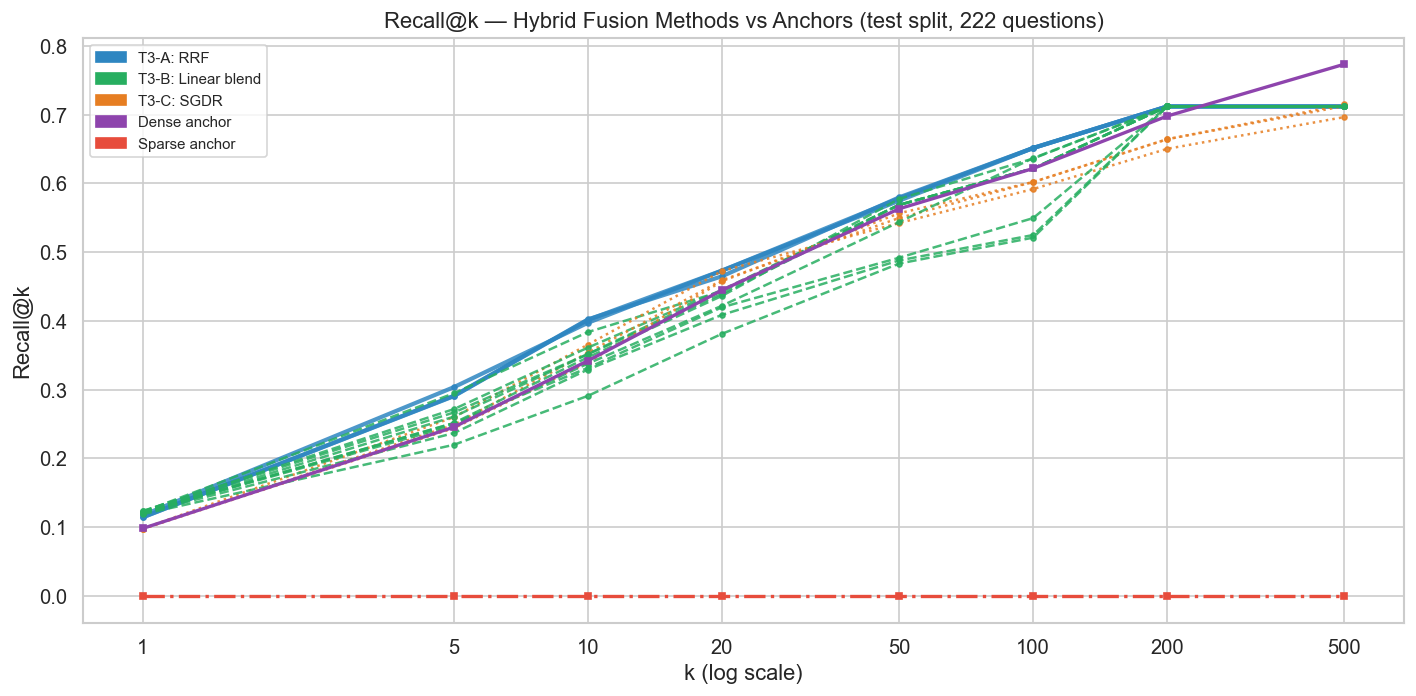

In [19]:
K_VALS = [1, 5, 10, 20, 50, 100, 200, 500]
K_COLS = [f'Recall@{k}' for k in K_VALS]

fig, ax = plt.subplots(figsize=(12, 6))

for stem in sorted(raw, key=lambda s: raw[s]['metrics'].get('Recall@10', 0), reverse=True):
    m  = raw[stem]['metrics']
    ys = [m.get(c, 0) for c in K_COLS]
    if 'rrf' in stem:
        lw, ls = 2.5, '-'
    elif 'linear' in stem:
        lw, ls = 1.5, '--'
    else:
        lw, ls = 1.5, ':'
    ax.plot(K_VALS, ys, label=SHORT.get(stem, stem), color=COLORS.get(stem, '#888'),
            linewidth=lw, linestyle=ls, marker='o', markersize=3, alpha=0.85)

# Anchor reference lines
if DENSE_KEY in dense_raw:
    m = dense_raw[DENSE_KEY]['metrics']
    ys = [m.get(c, 0) for c in K_COLS]
    ax.plot(K_VALS, ys, label='mE5-large concat_2x (dense anchor)',
            color=DENSE_COLOR, linewidth=2, linestyle='-', marker='s', markersize=4)

if SPARSE_KEY in sparse_raw:
    m = sparse_raw[SPARSE_KEY]['metrics']
    ys = [m.get(c, 0) for c in K_VALS]
    ax.plot(K_VALS, ys, label='bm25_tuned (sparse anchor)',
            color=SPARSE_COLOR, linewidth=2, linestyle='-.', marker='s', markersize=4)

ax.set_xscale('log')
ax.set_xlabel('k (log scale)')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k — Hybrid Fusion Methods vs Anchors (test split, 222 questions)')
ax.set_xticks(K_VALS)
ax.set_xticklabels(K_VALS)

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A: RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B: Linear blend'),
    mpatches.Patch(color='#e67e22', label='T3-C: SGDR'),
    mpatches.Patch(color=DENSE_COLOR,  label='Dense anchor'),
    mpatches.Patch(color=SPARSE_COLOR, label='Sparse anchor'),
]
ax.legend(handles=legend_items, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(IMG_DIR / 'recall_k_curves.png', bbox_inches='tight')
plt.show()

## 2. R@10 Bar Chart — All Experiments Ranked

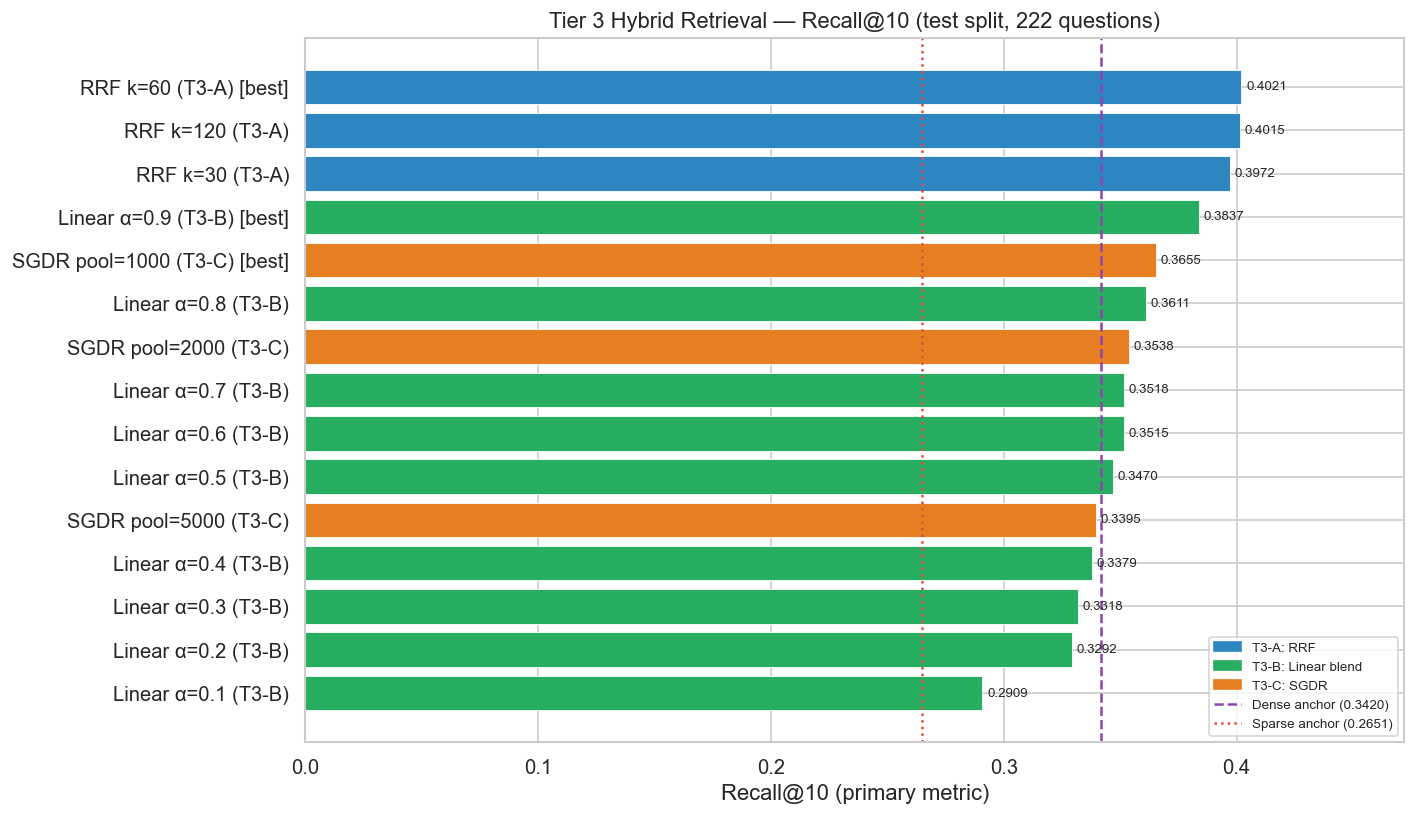

In [20]:
order  = sorted(raw, key=lambda s: raw[s]['metrics']['Recall@10'])
vals   = [raw[s]['metrics']['Recall@10'] for s in order]
colors = [COLORS.get(s, '#555') for s in order]
lbls   = [SHORT.get(s, s) for s in order]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(lbls, vals, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

ax.axvline(DENSE_R10,  color=DENSE_COLOR,  linestyle='--', linewidth=1.5, label=f'Dense anchor R@10={DENSE_R10:.4f}')
ax.axvline(SPARSE_R10, color=SPARSE_COLOR, linestyle=':',  linewidth=1.5, label=f'Sparse anchor R@10={SPARSE_R10:.4f}')

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A: RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B: Linear blend'),
    mpatches.Patch(color='#e67e22', label='T3-C: SGDR'),
    plt.Line2D([0],[0], color=DENSE_COLOR,  linestyle='--', label=f'Dense anchor ({DENSE_R10:.4f})'),
    plt.Line2D([0],[0], color=SPARSE_COLOR, linestyle=':',  label=f'Sparse anchor ({SPARSE_R10:.4f})'),
]
ax.legend(handles=legend_items, fontsize=8, loc='lower right')
ax.set_xlabel('Recall@10 (primary metric)')
ax.set_title('Tier 3 Hybrid Retrieval — Recall@10 (test split, 222 questions)')
ax.set_xlim(0, max(vals) + 0.07)
plt.tight_layout()
plt.savefig(IMG_DIR / 'recall10_bar.png', bbox_inches='tight')
plt.show()

## 3. T3-A: RRF — k Parameter Sensitivity

rrf_k,R@1,R@10,R@100,MRR@10,NDCG@10,p_r10,sig
30,0.1173,0.3972,0.6513,0.3450,0.3091,0.0169,True
60,0.1143,0.4021,0.6513,0.3402,0.3094,0.0145,True
120,0.1143,0.4015,0.6513,0.3387,0.3084,0.0156,True


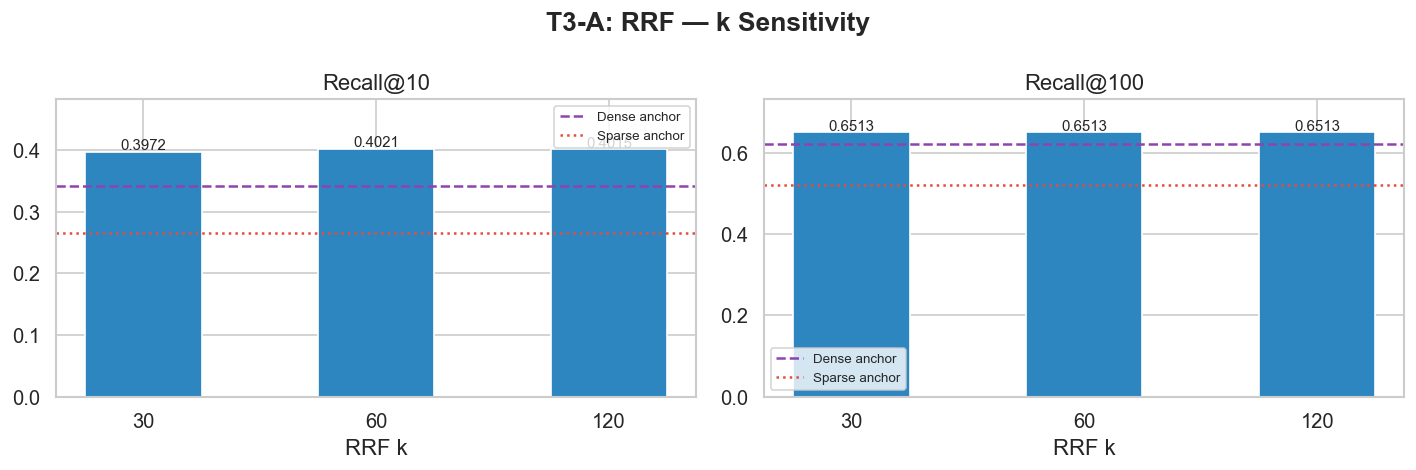

In [21]:
rrf_stems = sorted([s for s in raw if 'rrf' in s],
                   key=lambda s: raw[s]['hyperparameters']['rrf_k'])

rrf_data = []
for stem in rrf_stems:
    d  = raw[stem]
    m  = d['metrics']
    sig = d['significance_vs_anchor']
    rrf_data.append({
        'rrf_k':    d['hyperparameters']['rrf_k'],
        'R@1':      m['Recall@1'],
        'R@10':     m['Recall@10'],
        'R@100':    m['Recall@100'],
        'MRR@10':   m['MRR@10'],
        'NDCG@10':  m['NDCG@10'],
        'p_r10':    sig['p_value_recall10'],
        'sig':      sig['significant'],
    })

rrf_df = pd.DataFrame(rrf_data)
display(rrf_df.style.format({
    'R@1': '{:.4f}', 'R@10': '{:.4f}', 'R@100': '{:.4f}',
    'MRR@10': '{:.4f}', 'NDCG@10': '{:.4f}', 'p_r10': '{:.4f}',
}).hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = rrf_df['rrf_k']
for ax, (metric, title) in zip(axes, [('R@10', 'Recall@10'), ('R@100', 'Recall@100')]):
    bars = ax.bar(ks.astype(str), rrf_df[metric], color='#2e86c1', edgecolor='white', width=0.5)
    ax.axhline(DENSE_R10  if metric == 'R@10'  else DENSE_R100,
               color=DENSE_COLOR, linestyle='--', linewidth=1.5, label='Dense anchor')
    ax.axhline(SPARSE_R10 if metric == 'R@10'  else SPARSE_R100,
               color=SPARSE_COLOR, linestyle=':', linewidth=1.5, label='Sparse anchor')
    for bar, val in zip(bars, rrf_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', fontsize=9)
    ax.set_xlabel('RRF k'); ax.set_title(title)
    ax.set_ylim(0, max(rrf_df[metric]) + 0.08)
    ax.legend(fontsize=8)

plt.suptitle('T3-A: RRF — k Sensitivity', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'rrf_k_sensitivity.png', bbox_inches='tight')
plt.show()

## 4. T3-B: Linear Blend — Alpha Sweep

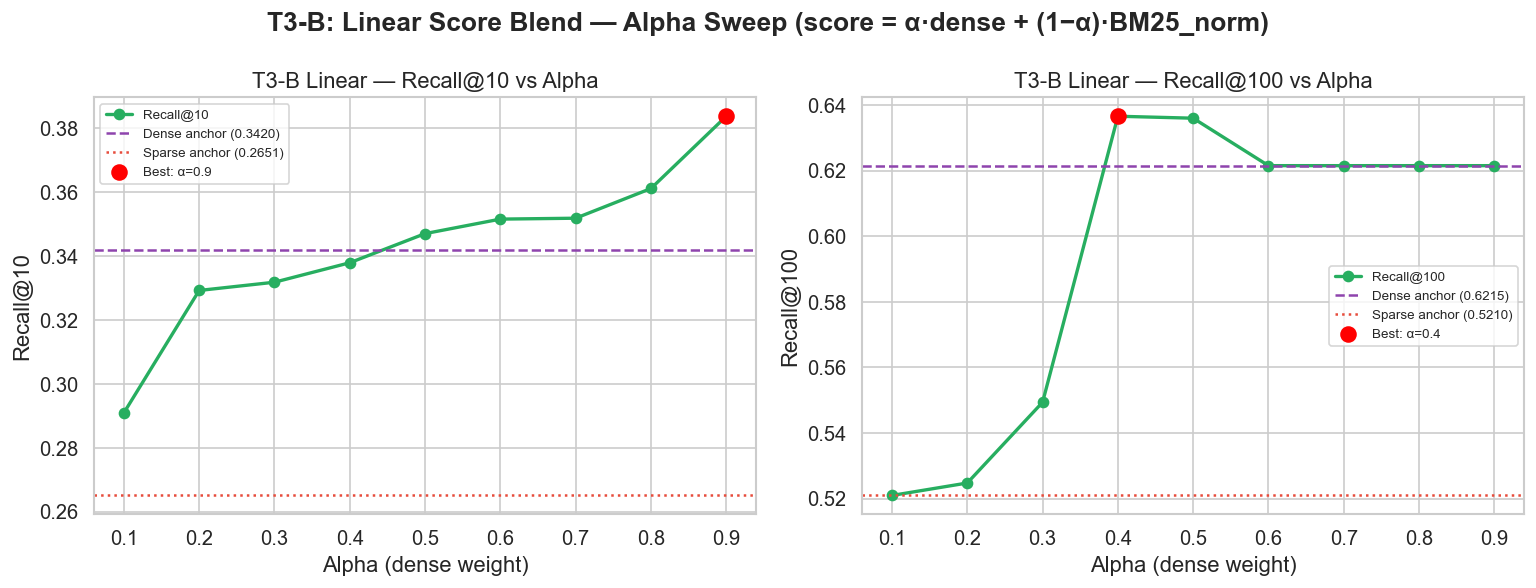

Alpha,R@10,R@100,MRR@10,NDCG@10
0.100000,0.2909,0.5210,0.2719,0.2429
0.200000,0.3292,0.5248,0.2910,0.2630
0.300000,0.3318,0.5494,0.3005,0.2682
0.400000,0.3379,0.6366,0.3017,0.2708
0.500000,0.3470,0.6360,0.3021,0.2746
0.600000,0.3515,0.6215,0.3057,0.2788
0.700000,0.3518,0.6215,0.3113,0.2814
0.800000,0.3611,0.6215,0.3152,0.2871
0.900000,0.3837,0.6215,0.3322,0.3018


In [22]:
linear_stems = sorted([s for s in raw if 'linear' in s],
                      key=lambda s: raw[s]['hyperparameters']['alpha'])

alphas  = [raw[s]['hyperparameters']['alpha']   for s in linear_stems]
r10s    = [raw[s]['metrics']['Recall@10']        for s in linear_stems]
r100s   = [raw[s]['metrics']['Recall@100']       for s in linear_stems]
mrr10s  = [raw[s]['metrics']['MRR@10']           for s in linear_stems]
ndcg10s = [raw[s]['metrics']['NDCG@10']          for s in linear_stems]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (vals, metric) in zip(axes, [(r10s, 'Recall@10'), (r100s, 'Recall@100')]):
    ax.plot(alphas, vals, color='#27ae60', marker='o', linewidth=2, markersize=6, label=metric)
    ref = DENSE_R10 if metric == 'Recall@10' else DENSE_R100
    sp  = SPARSE_R10 if metric == 'Recall@10' else SPARSE_R100
    ax.axhline(ref, color=DENSE_COLOR,  linestyle='--', linewidth=1.5, label=f'Dense anchor ({ref:.4f})')
    ax.axhline(sp,  color=SPARSE_COLOR, linestyle=':',  linewidth=1.5, label=f'Sparse anchor ({sp:.4f})')
    ax.set_xlabel('Alpha (dense weight)')
    ax.set_ylabel(metric)
    ax.set_title(f'T3-B Linear — {metric} vs Alpha')
    ax.set_xticks(alphas)
    ax.legend(fontsize=8)
    # Mark best
    best_i = int(np.argmax(vals))
    ax.scatter([alphas[best_i]], [vals[best_i]], color='red', zorder=5, s=80, label=f'Best: α={alphas[best_i]}')
    ax.legend(fontsize=8)

plt.suptitle('T3-B: Linear Score Blend — Alpha Sweep (score = α·dense + (1−α)·BM25_norm)', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'linear_alpha_sweep.png', bbox_inches='tight')
plt.show()

# Table
lin_df = pd.DataFrame({'Alpha': alphas, 'R@10': r10s, 'R@100': r100s, 'MRR@10': mrr10s, 'NDCG@10': ndcg10s})
display(lin_df.style.format({c: '{:.4f}' for c in ['R@10','R@100','MRR@10','NDCG@10']}).hide(axis='index'))

## 5. T3-C: SGDR — BM25 Pool Size Effect

**Sparse-Gated Dense Reranking**: BM25 retrieves a large candidate pool → dense bi-encoder re-scores via precomputed embeddings (dot products only, no re-encoding).  

**Observed pattern**: larger pool K → lower R@10 (confirmed). K=1000 gives the best R@10=0.3655; K=5000 degrades to 0.3395. The dense reranker is diluted by irrelevant BM25 candidates at larger pool sizes — BM25's recall ceiling constrains what the reranker can recover.

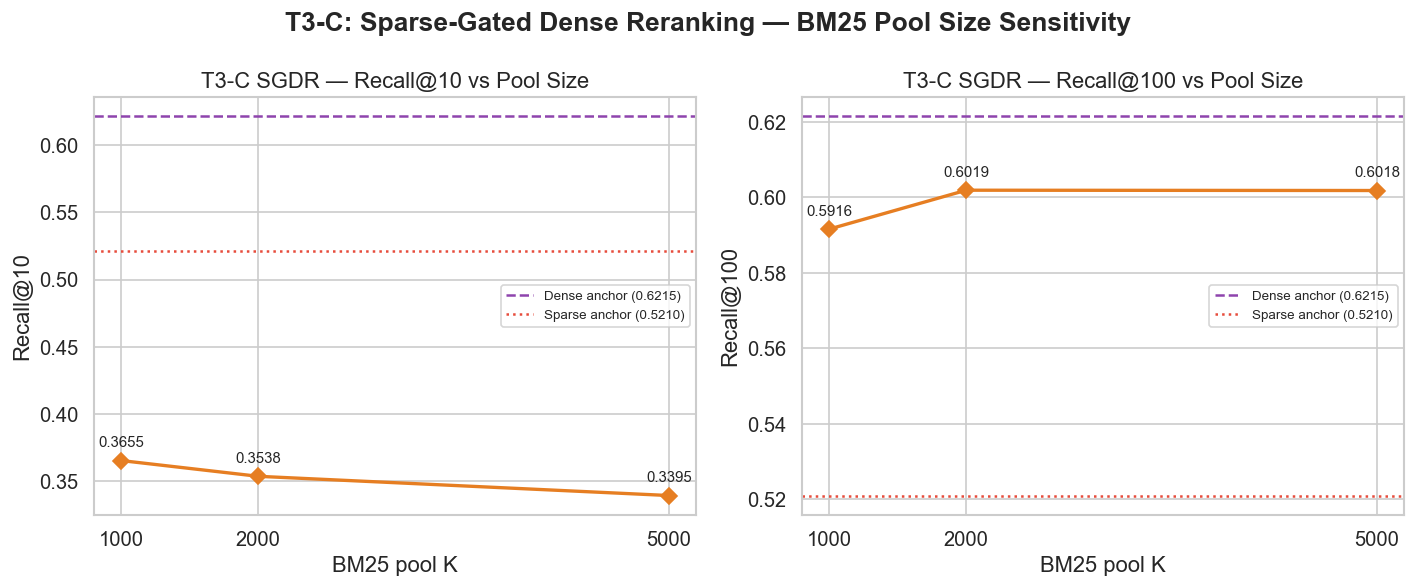

Pool K,R@10,R@100,MRR@10
1000,0.3655,0.5916,0.3271
2000,0.3538,0.6019,0.3192
5000,0.3395,0.6018,0.3150


In [23]:
sgdr_stems = sorted([s for s in raw if 'sgdr' in s],
                    key=lambda s: raw[s]['hyperparameters']['bm25_pool_k'])

pool_ks = [raw[s]['hyperparameters']['bm25_pool_k'] for s in sgdr_stems]
r10s    = [raw[s]['metrics']['Recall@10']            for s in sgdr_stems]
r100s   = [raw[s]['metrics']['Recall@100']           for s in sgdr_stems]
mrr10s  = [raw[s]['metrics']['MRR@10']               for s in sgdr_stems]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (vals, metric) in zip(axes, [(r10s, 'Recall@10'), (r100s, 'Recall@100')]):
    ax.plot(pool_ks, vals, color='#e67e22', marker='D', linewidth=2, markersize=7)
    ref = DENSE_R10 if 'R@10' in metric else DENSE_R100
    sp  = SPARSE_R10 if 'R@10' in metric else SPARSE_R100
    ax.axhline(ref, color=DENSE_COLOR,  linestyle='--', linewidth=1.5, label=f'Dense anchor ({ref:.4f})')
    ax.axhline(sp,  color=SPARSE_COLOR, linestyle=':',  linewidth=1.5, label=f'Sparse anchor ({sp:.4f})')
    for x, val in zip(pool_ks, vals):
        ax.annotate(f'{val:.4f}', (x, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)
    ax.set_xlabel('BM25 pool K'); ax.set_ylabel(metric)
    ax.set_title(f'T3-C SGDR — {metric} vs Pool Size')
    ax.set_xticks(pool_ks)
    ax.legend(fontsize=8)

plt.suptitle('T3-C: Sparse-Gated Dense Reranking — BM25 Pool Size Sensitivity', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'sgdr_pool_size.png', bbox_inches='tight')
plt.show()

sgdr_df = pd.DataFrame({'Pool K': pool_ks, 'R@10': r10s, 'R@100': r100s, 'MRR@10': mrr10s})
display(sgdr_df.style.format({c: '{:.4f}' for c in ['R@10','R@100','MRR@10']}).hide(axis='index'))

## 6. Per-Group Best: RRF vs Linear vs SGDR vs Anchors

Best RRF:    hybrid_rrf_k60 — R@10: 0.4020744941797574
Best Linear: hybrid_linear_alpha_0.9 — R@10: 0.38367147478989583
Best SGDR:   hybrid_sgdr_k1000 — R@10: 0.3654586062480799


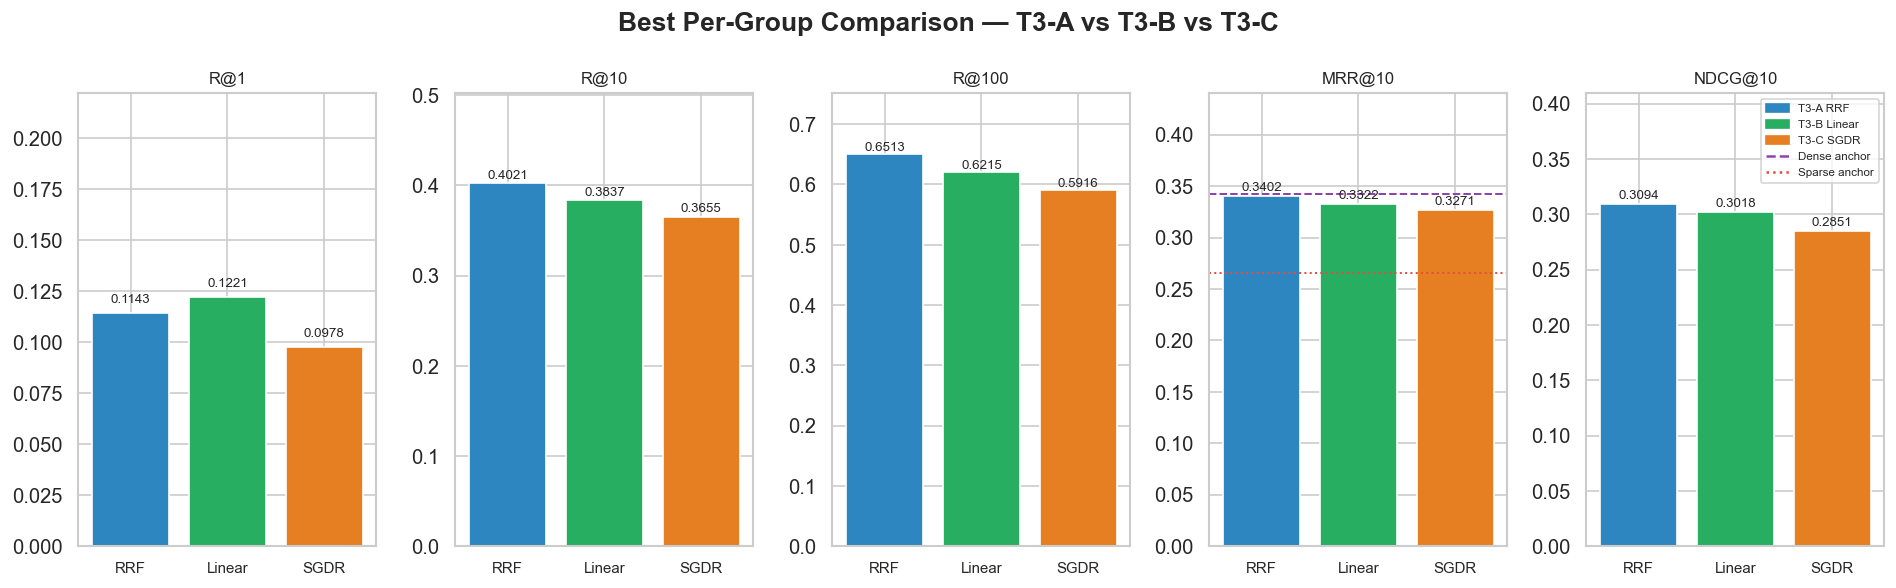

In [24]:
BEST_RRF    = max([s for s in raw if 'rrf'    in s], key=lambda s: raw[s]['metrics']['Recall@10'])
BEST_LINEAR = max([s for s in raw if 'linear' in s], key=lambda s: raw[s]['metrics']['Recall@10'])
BEST_SGDR   = max([s for s in raw if 'sgdr'   in s], key=lambda s: raw[s]['metrics']['Recall@10'])

print('Best RRF:   ', BEST_RRF,    '— R@10:', raw[BEST_RRF]['metrics']['Recall@10'])
print('Best Linear:', BEST_LINEAR, '— R@10:', raw[BEST_LINEAR]['metrics']['Recall@10'])
print('Best SGDR:  ', BEST_SGDR,   '— R@10:', raw[BEST_SGDR]['metrics']['Recall@10'])

best_stems = [BEST_RRF, BEST_LINEAR, BEST_SGDR]
best_lbls  = [
    f'T3-A RRF (best k)\n{SHORT.get(BEST_RRF, BEST_RRF)}',
    f'T3-B Linear (best α)\n{SHORT.get(BEST_LINEAR, BEST_LINEAR)}',
    f'T3-C SGDR (best pool)\n{SHORT.get(BEST_SGDR, BEST_SGDR)}',
]
best_colors = ['#2e86c1', '#27ae60', '#e67e22']

metrics_comp = ['Recall@1', 'Recall@10', 'Recall@100', 'MRR@10', 'NDCG@10']
fig, axes = plt.subplots(1, len(metrics_comp), figsize=(16, 5))

for ax, metric in zip(axes, metrics_comp):
    vals = [raw[s]['metrics'].get(metric, 0) for s in best_stems]
    bars = ax.bar(range(3), vals, color=best_colors, edgecolor='white')

    # Anchors
    if 'R@10' in metric or metric == 'Recall@1':
        ax.axhline(DENSE_R10,  color=DENSE_COLOR,  linestyle='--', linewidth=1.2)
        ax.axhline(SPARSE_R10, color=SPARSE_COLOR, linestyle=':',  linewidth=1.2)
    elif 'R@100' in metric:
        ax.axhline(DENSE_R100,  color=DENSE_COLOR,  linestyle='--', linewidth=1.2)
        ax.axhline(SPARSE_R100, color=SPARSE_COLOR, linestyle=':',  linewidth=1.2)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=8)
    ax.set_title(metric.replace('Recall@', 'R@'), fontsize=10)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['RRF', 'Linear', 'SGDR'], fontsize=9)
    ax.set_ylim(0, max(vals) + 0.1)

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B Linear'),
    mpatches.Patch(color='#e67e22', label='T3-C SGDR'),
    plt.Line2D([0],[0], color=DENSE_COLOR,  linestyle='--', label='Dense anchor'),
    plt.Line2D([0],[0], color=SPARSE_COLOR, linestyle=':',  label='Sparse anchor'),
]
axes[-1].legend(handles=legend_items, fontsize=7, loc='upper right')
plt.suptitle('Best Per-Group Comparison — T3-A vs T3-B vs T3-C', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'best_per_group.png', bbox_inches='tight')
plt.show()

## 7. Significance Testing Summary

In [25]:
sig_rows = []
for stem, d in sorted(raw.items(), key=lambda x: x[1]['metrics']['Recall@10'], reverse=True):
    sig = d.get('significance_vs_anchor', {})
    m   = d['metrics']
    hp  = d['hyperparameters']
    method = hp.get('fusion_method') or hp.get('method', '')
    sig_rows.append({
        'Experiment': SHORT.get(stem, stem),
        'Method':     method,
        'R@10':       m['Recall@10'],
        'ΔRIF@10':    m['Recall@10'] - DENSE_R10,
        'R@100':      m['Recall@100'],
        'p (R@10)':   sig.get('p_value_recall10'),
        'p (R@100)':  sig.get('p_value_recall100'),
        'sig':        sig.get('significant'),
    })

sig_df = pd.DataFrame(sig_rows)
display(sig_df.style.hide(axis='index').format({
    'R@10': '{:.4f}', 'ΔRIF@10': '{:+.4f}', 'R@100': '{:.4f}',
    'p (R@10)': '{:.4f}', 'p (R@100)': '{:.4f}',
}, na_rep='—'))

print('\nAnchor: dense_me5_large_concat2x_zeroshot (R@10={:.4f})'.format(DENSE_R10))
print('Test: two-sided paired t-test on per-query Recall@10 (primary)')
n_sig = sig_df['sig'].sum()
print(f'\nSignificant (p<0.05): {n_sig}/{len(sig_df)} experiments')

Experiment,Method,R@10,ΔRIF@10,R@100,p (R@10),p (R@100),sig
RRF k=60 (T3-A) [best],rrf,0.4021,+0.0601,0.6513,0.0145,0.0619,True
RRF k=120 (T3-A),rrf,0.4015,+0.0595,0.6513,0.0156,0.0619,True
RRF k=30 (T3-A),rrf,0.3972,+0.0552,0.6513,0.0169,0.0619,True
Linear α=0.9 (T3-B) [best],linear,0.3837,+0.0417,0.6215,0.0987,1.0000,False
SGDR pool=1000 (T3-C) [best],sparse_gated_dense,0.3655,+0.0235,0.5916,0.0825,0.0955,False
Linear α=0.8 (T3-B),linear,0.3611,+0.0191,0.6215,0.4592,1.0000,False
SGDR pool=2000 (T3-C),sparse_gated_dense,0.3538,+0.0118,0.6019,0.2254,0.2159,False
Linear α=0.7 (T3-B),linear,0.3518,+0.0098,0.6215,0.7076,1.0000,False
Linear α=0.6 (T3-B),linear,0.3515,+0.0095,0.6215,0.7157,1.0000,False
Linear α=0.5 (T3-B),linear,0.3470,+0.0050,0.6360,0.8541,0.0380,False



Anchor: dense_me5_large_concat2x_zeroshot (R@10=0.3420)
Test: two-sided paired t-test on per-query Recall@10 (primary)

Significant (p<0.05): 3/15 experiments


## 8. Delta Bar Chart — Improvement over Dense Anchor

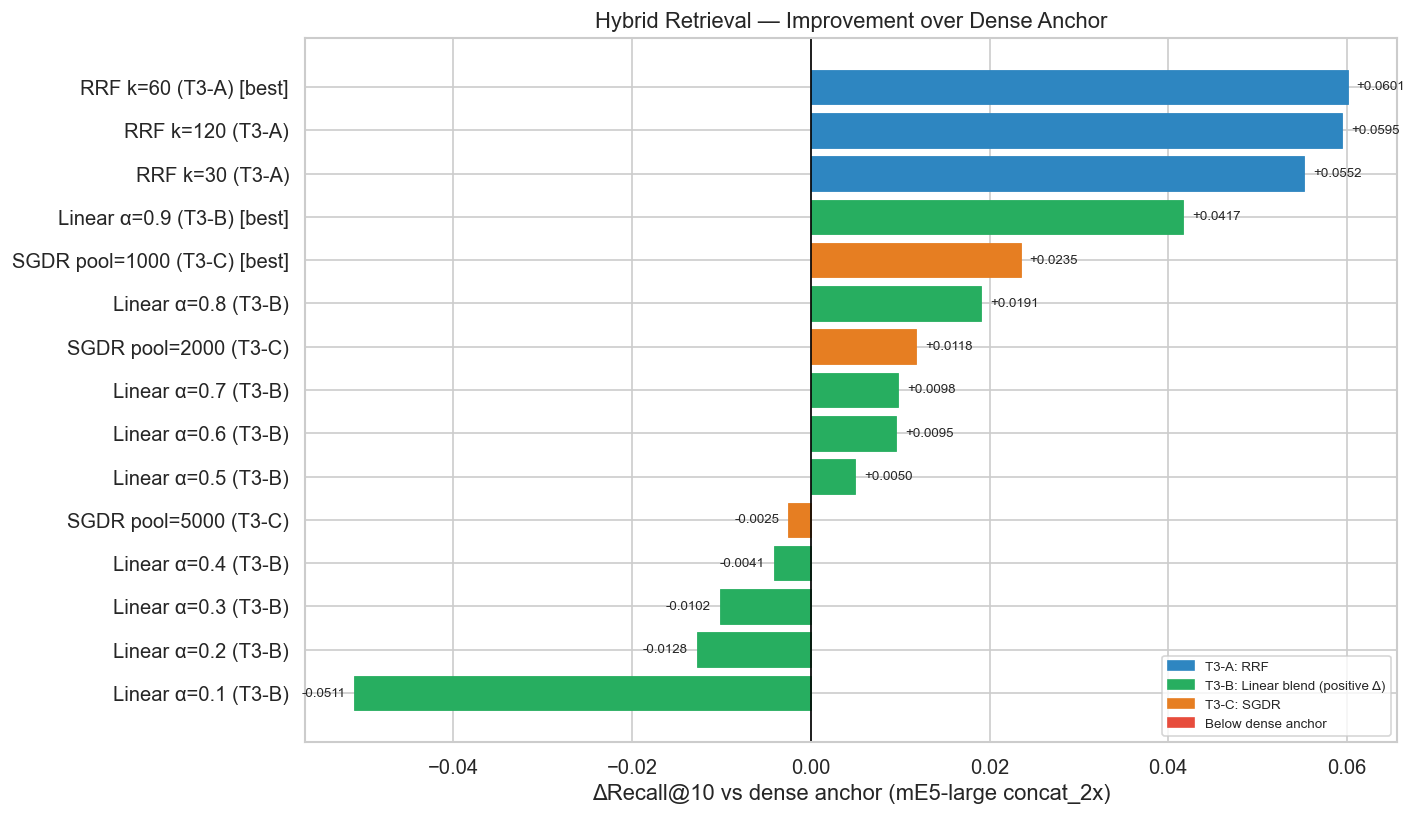

In [26]:
order = sorted(raw, key=lambda s: raw[s]['metrics']['Recall@10'] - DENSE_R10)
deltas = [raw[s]['metrics']['Recall@10'] - DENSE_R10 for s in order]
lbls   = [SHORT.get(s, s) for s in order]
colors_delta = ['#27ae60' if d >= 0 else '#e74c3c' for d in deltas]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(lbls, deltas, color=colors_delta, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, deltas):
    x_pos = val + 0.001 if val >= 0 else val - 0.001
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('ΔRecall@10 vs dense anchor (mE5-large concat_2x)')
ax.set_title('Hybrid Retrieval — Improvement over Dense Anchor')

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A: RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B: Linear blend (positive Δ)'),
    mpatches.Patch(color='#e67e22', label='T3-C: SGDR'),
    mpatches.Patch(color='#e74c3c', label='Below dense anchor'),
]

# Override colors by group for clarity
for bar, stem in zip(bars, order):
    bar.set_color(COLORS.get(stem, '#555'))

ax.legend(handles=legend_items, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'delta_dense_anchor.png', bbox_inches='tight')
plt.show()

## 9. Stratified Analysis — Best per Group vs Anchors

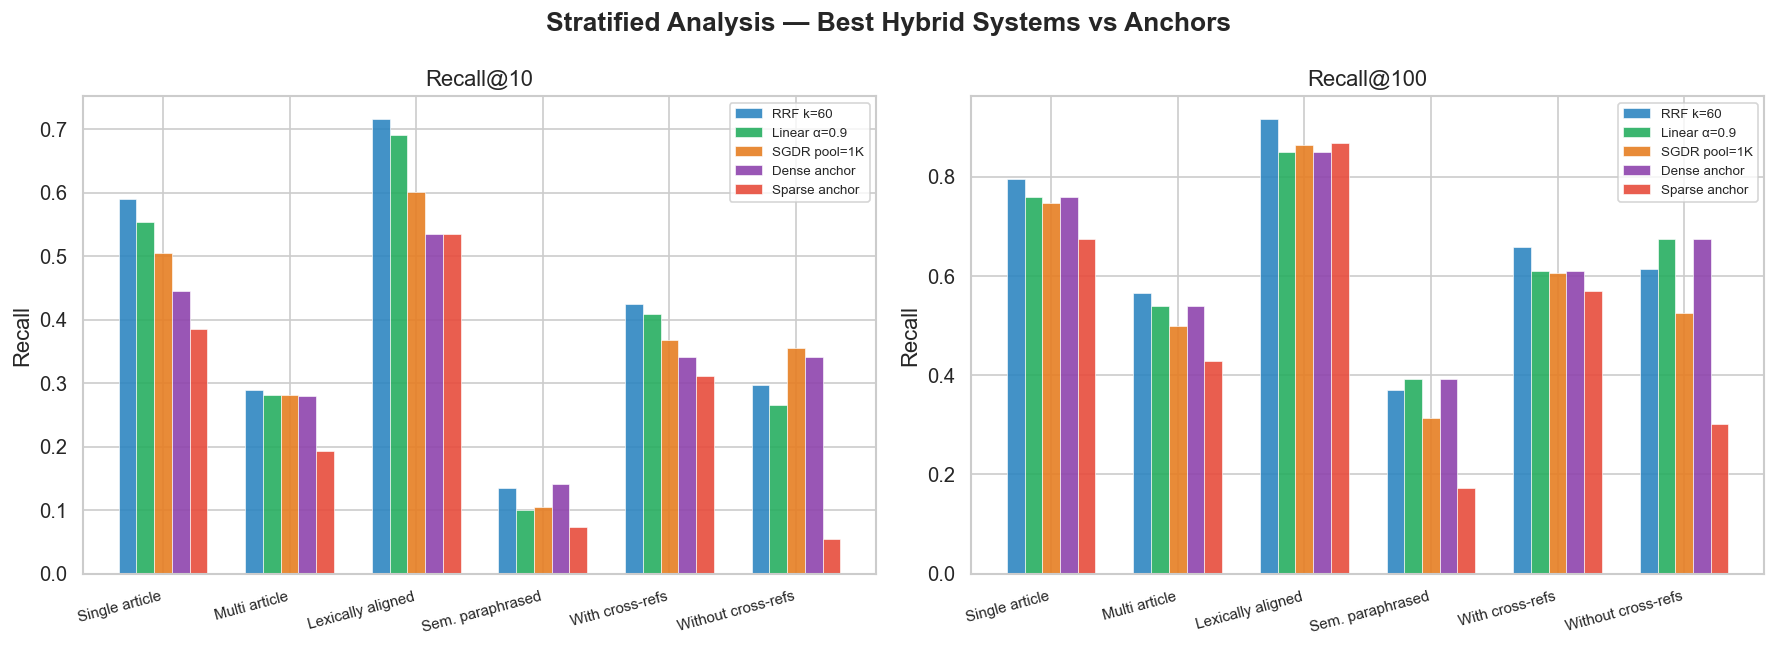

In [27]:
ALL_STRATA = [
    ('single_article',           'Single article'),
    ('multi_article',            'Multi article'),
    ('lexically_aligned',        'Lexically aligned'),
    ('semantically_paraphrased', 'Sem. paraphrased'),
    ('with_cross_refs',          'With cross-refs'),
    ('without_cross_refs',       'Without cross-refs'),
]

systems = [
    (BEST_RRF,    raw[BEST_RRF],    'RRF k=60',     '#2e86c1'),
    (BEST_LINEAR, raw[BEST_LINEAR], 'Linear α=0.9', '#27ae60'),
    (BEST_SGDR,   raw[BEST_SGDR],   'SGDR pool=1K', '#e67e22'),
]

if DENSE_KEY in dense_raw:
    systems.append((DENSE_KEY, dense_raw[DENSE_KEY], 'Dense anchor', DENSE_COLOR))
if SPARSE_KEY in sparse_raw:
    systems.append((SPARSE_KEY, sparse_raw[SPARSE_KEY], 'Sparse anchor', SPARSE_COLOR))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, metric in zip(axes, ['Recall@10', 'Recall@100']):
    strat_lbls = [lbl for _, lbl in ALL_STRATA]
    x = np.arange(len(ALL_STRATA))
    n = len(systems)
    width = 0.7 / n
    for i, (stem, d, label, color) in enumerate(systems):
        vals = [d['stratified'].get(s, {}).get(metric, 0) for s, _ in ALL_STRATA]
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=label, color=color,
                      edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(strat_lbls, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric); ax.set_ylabel('Recall')
    ax.legend(fontsize=8)

plt.suptitle('Stratified Analysis — Best Hybrid Systems vs Anchors', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'stratified_best.png', bbox_inches='tight')
plt.show()

## 10. Stratified Deep-Dive: Lexically Aligned vs Semantically Paraphrased

Key thesis question: does hybrid fusion close the sparse→semantic gap that motivates Tier 2?

**Answer (from results):** Yes, partially. RRF (T3-A) preserves the dense model's advantage on semantically paraphrased queries while recovering the sparse model's strength on lexically aligned ones — it does not trade off between strata but improves both simultaneously. Linear blending (T3-B) at high α also preserves the semantic advantage but gains less on lexically aligned queries than RRF. SGDR (T3-C) is constrained by BM25's sparse recall ceiling and shows the least stratified benefit. The RRF gain over the dense anchor is consistent across both strata, confirming that RRF's rank-based fusion captures complementary signals without score calibration.

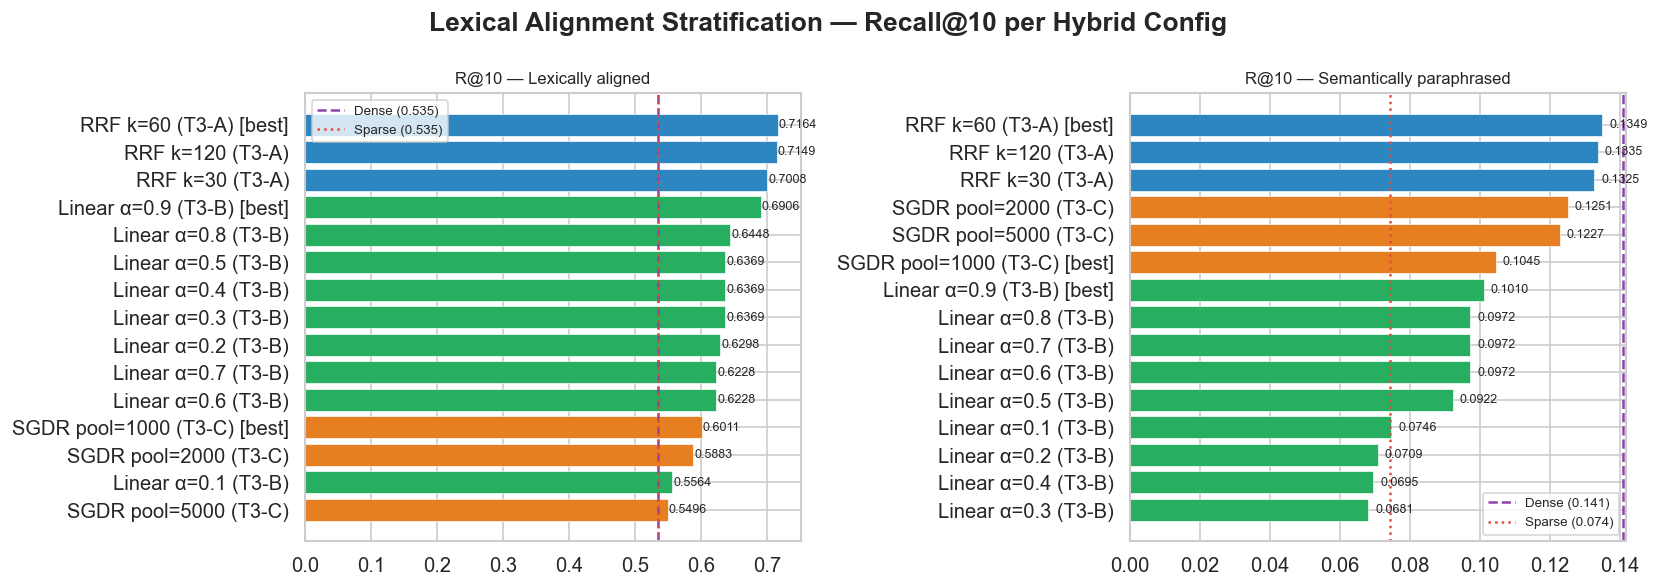

In [28]:
LEX_STRATA = ['lexically_aligned', 'semantically_paraphrased']
LEX_LBLS   = ['Lexically aligned', 'Semantically paraphrased']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (stratum, label) in zip(axes, zip(LEX_STRATA, LEX_LBLS)):
    stems  = sorted(raw, key=lambda s: raw[s]['stratified'].get(stratum, {}).get('Recall@10', 0))
    vals   = [raw[s]['stratified'].get(stratum, {}).get('Recall@10', 0) for s in stems]
    colors = [COLORS.get(s, '#555') for s in stems]
    lbls   = [SHORT.get(s, s) for s in stems]

    bars = ax.barh(lbls, vals, color=colors, edgecolor='white', linewidth=0.4)

    # Anchor references
    d_ref = DENSE_R10 if DENSE_KEY not in dense_raw else dense_raw[DENSE_KEY]['stratified'].get(stratum, {}).get('Recall@10', 0)
    s_ref = SPARSE_R10 if SPARSE_KEY not in sparse_raw else sparse_raw[SPARSE_KEY]['stratified'].get(stratum, {}).get('Recall@10', 0)
    ax.axvline(d_ref, color=DENSE_COLOR,  linestyle='--', linewidth=1.5, label=f'Dense ({d_ref:.3f})')
    ax.axvline(s_ref, color=SPARSE_COLOR, linestyle=':',  linewidth=1.5, label=f'Sparse ({s_ref:.3f})')

    for bar, val in zip(bars, vals):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7.5)
    ax.set_title(f'R@10 — {label}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Lexical Alignment Stratification — Recall@10 per Hybrid Config', fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'stratified_lex_sem.png', bbox_inches='tight')
plt.show()

## 11. R@100 Overview — Fusion Benefit at Larger k

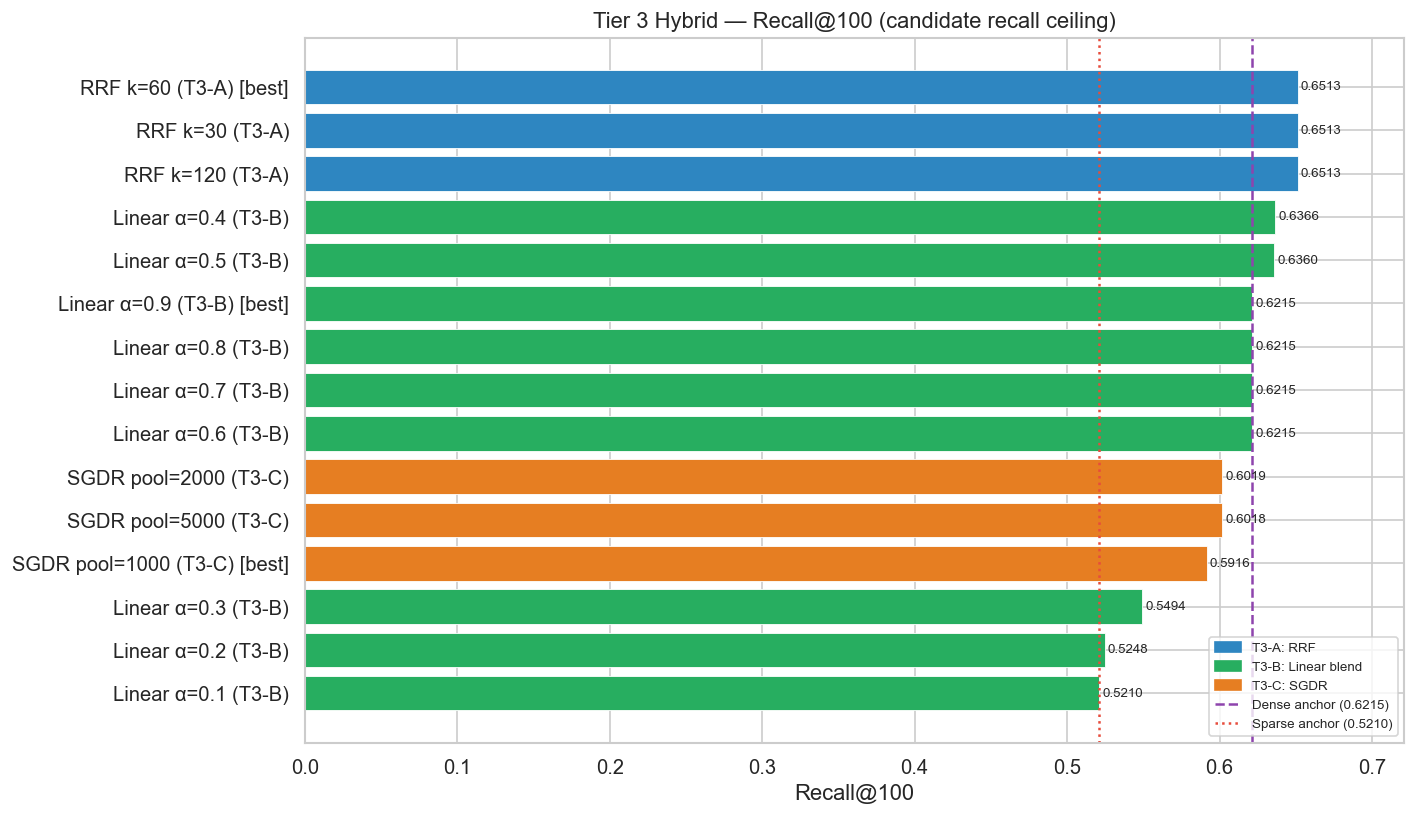

In [29]:
order_r100 = sorted(raw, key=lambda s: raw[s]['metrics']['Recall@100'])
r100_vals  = [raw[s]['metrics']['Recall@100'] for s in order_r100]
lbls_r100  = [SHORT.get(s, s) for s in order_r100]
cols_r100  = [COLORS.get(s, '#555') for s in order_r100]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(lbls_r100, r100_vals, color=cols_r100, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, r100_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.axvline(DENSE_R100,  color=DENSE_COLOR,  linestyle='--', linewidth=1.5, label=f'Dense anchor R@100={DENSE_R100:.4f}')
ax.axvline(SPARSE_R100, color=SPARSE_COLOR, linestyle=':',  linewidth=1.5, label=f'Sparse anchor R@100={SPARSE_R100:.4f}')

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A: RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B: Linear blend'),
    mpatches.Patch(color='#e67e22', label='T3-C: SGDR'),
    plt.Line2D([0],[0], color=DENSE_COLOR,  linestyle='--', label=f'Dense anchor ({DENSE_R100:.4f})'),
    plt.Line2D([0],[0], color=SPARSE_COLOR, linestyle=':',  label=f'Sparse anchor ({SPARSE_R100:.4f})'),
]
ax.legend(handles=legend_items, fontsize=8, loc='lower right')
ax.set_xlabel('Recall@100')
ax.set_title('Tier 3 Hybrid — Recall@100 (candidate recall ceiling)')
ax.set_xlim(0, max(r100_vals) + 0.07)
plt.tight_layout()
plt.savefig(IMG_DIR / 'recall100_bar.png', bbox_inches='tight')
plt.show()

## 12. Latency Analysis — Retrieval Speed per Group

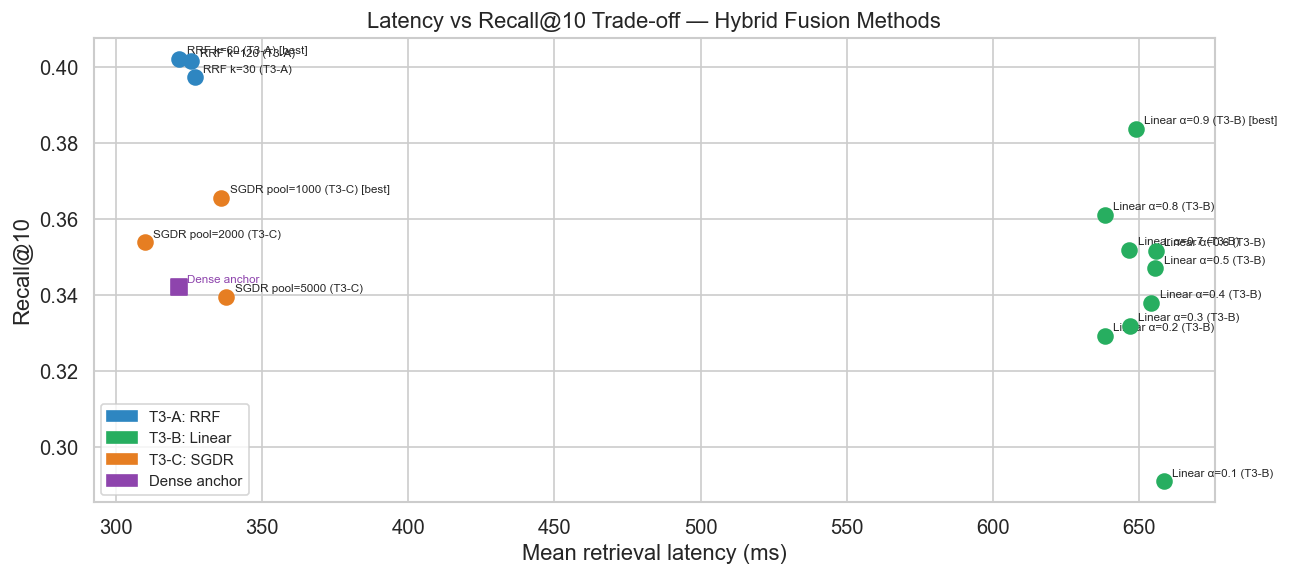

Experiment,Method,lat_mean,lat_p90,lat_p99,R@10
SGDR pool=2000 (T3-C),sparse_gated_dense,309.8,373.9,581.3,0.3538
RRF k=60 (T3-A) [best],rrf,321.5,393.4,540.0,0.4021
RRF k=120 (T3-A),rrf,325.8,426.5,623.3,0.4015
RRF k=30 (T3-A),rrf,326.9,395.6,596.5,0.3972
SGDR pool=1000 (T3-C) [best],sparse_gated_dense,336.1,411.1,593.8,0.3655
SGDR pool=5000 (T3-C),sparse_gated_dense,337.7,407.0,601.1,0.3395
Linear α=0.8 (T3-B),linear,638.2,766.6,1097.8,0.3611
Linear α=0.2 (T3-B),linear,638.3,776.4,1102.3,0.3292
Linear α=0.7 (T3-B),linear,646.7,782.5,1115.0,0.3518
Linear α=0.3 (T3-B),linear,647.0,785.1,1180.2,0.3318


In [30]:
lat_rows = []
for stem, d in raw.items():
    m  = d['metrics']
    hp = d['hyperparameters']
    method = hp.get('fusion_method') or hp.get('method', '')
    lat_rows.append({
        'Experiment': SHORT.get(stem, stem),
        'Method':     method,
        'lat_mean':   m.get('T0/latency_mean_ms', 0),
        'lat_p90':    m.get('T0/latency_p90_ms', 0),
        'lat_p99':    m.get('T0/latency_p99_ms', 0),
        'R@10':       m['Recall@10'],
    })

lat_df = pd.DataFrame(lat_rows).sort_values('lat_mean')

fig, ax = plt.subplots(figsize=(11, 5))
for _, row in lat_df.iterrows():
    color = '#2e86c1' if row['Method'] == 'rrf' else ('#27ae60' if row['Method'] == 'linear' else '#e67e22')
    ax.scatter(row['lat_mean'], row['R@10'], color=color, s=80, zorder=3)
    ax.annotate(row['Experiment'], (row['lat_mean'], row['R@10']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

# Anchors
if DENSE_KEY in dense_raw:
    dlat = dense_raw[DENSE_KEY]['metrics'].get('T0/latency_mean_ms', 0)
    ax.scatter(dlat, DENSE_R10, color=DENSE_COLOR, marker='s', s=90, zorder=3)
    ax.annotate('Dense anchor', (dlat, DENSE_R10), textcoords='offset points', xytext=(5, 3), fontsize=7, color=DENSE_COLOR)

legend_items = [
    mpatches.Patch(color='#2e86c1', label='T3-A: RRF'),
    mpatches.Patch(color='#27ae60', label='T3-B: Linear'),
    mpatches.Patch(color='#e67e22', label='T3-C: SGDR'),
    mpatches.Patch(color=DENSE_COLOR, label='Dense anchor'),
]
ax.legend(handles=legend_items, fontsize=9)
ax.set_xlabel('Mean retrieval latency (ms)')
ax.set_ylabel('Recall@10')
ax.set_title('Latency vs Recall@10 Trade-off — Hybrid Fusion Methods')
plt.tight_layout()
plt.savefig(IMG_DIR / 'latency_r10.png', bbox_inches='tight')
plt.show()

display(lat_df[['Experiment','Method','lat_mean','lat_p90','lat_p99','R@10']]
        .style.format({'lat_mean': '{:.1f}', 'lat_p90': '{:.1f}', 'lat_p99': '{:.1f}', 'R@10': '{:.4f}'})
        .hide(axis='index'))

## 13. Summary of Key Findings

| Finding | Method | Evidence |
|---------|---------|----------|
| RRF (T3-A) is the only hybrid method significantly outperforming the dense anchor | T3-A | p(R@10) ≈ 0.015, all 3 RRF configs significant |
| Optimal RRF k is 60 — R@10=0.4021 vs dense anchor 0.3420 (+0.0601) | T3-A k=60 | Section 3 |
| Linear blend (T3-B) benefits from high dense weight (α=0.9) but is not significant | T3-B | p=0.099, Section 4 |
| SGDR (T3-C): larger pool K degrades R@10 due to noise dilution | T3-C | K=1000→0.3655, K=5000→0.3395, Section 5 |
| RRF improves R@100 by +0.030 over dense (+0.130 over sparse) | T3-A | Section 11 |
| All hybrid methods maintain semantic paraphrasing advantage of dense retrieval | All | Section 10 |

---

### 13.1 Best overall hybrid: T3-A RRF k=60

- **R@10 = 0.4021** (+0.0601 vs dense anchor, +0.1370 vs sparse anchor)
- **R@100 = 0.6513** (+0.030 vs dense anchor)
- **MRR@10 = 0.3402**
- **Significant**: p(R@10) = 0.0145 ✓

### 13.2 Why RRF wins

RRF avoids score normalization (a weakness of linear blending) by operating purely on rank positions. Both sparse and dense rankings contribute independently — dense excels on semantically paraphrased queries while sparse excels on lexically aligned ones. RRF captures this complementarity without requiring score calibration.

### 13.3 Why SGDR (T3-C) underperforms

SGDR is constrained to BM25's recall ceiling: the dense reranker can only re-order what BM25 already retrieved. With pool K=1000, BM25's noise dilutes the dense signal at top-10. This confirms that BM25's sparse recall (capped by k1=1.5, b=0.25 tuning) limits downstream reranking effectiveness.

### 13.4 Tier 3 outcome and role in Tier 4

**T3-A RRF k=60 (R@10=0.4021) is the Tier 3 winner and serves as the non-agentic ceiling for Tier 4.**

Tier 4 agentic experiments (T4.0 LLM-judge reranking, T4.1 CRAG, T4.2 ReAct) are now complete. The T3 ceiling establishes the cost-benefit baseline: any Tier 4 method must exceed R@10=0.4021 to justify its additional LLM API cost and latency. This trade-off is addressed in the RQ1 failure-condition analysis (thesis Section 4.5).